<a href="https://colab.research.google.com/github/69-69/MS-in-Computer-Science-2025/blob/main/Project_2_Grad_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graduate Level-2 Cluster Analysis - COVID-19 + Vaccinationn Dataset

### 1. Mount Drive
> **HINT: Switch to Python Runtime to Mount the Google Drive**


In [ ]:
# Step 1: Mount Google Drive (in a Python cell)
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **HINT: Switch back to R Runtime to Access the Files in the Working Dir.**

In [ ]:
# Step 2: Access your files in R (in an R cell)

# Set working directory to your folder inside Google Drive
setwd("/content/drive/My Drive/MS-CS-Southern-Methodist-University-2024-may-2026/Data-Mining/Project-1/COVID-19-Data/")

# Optional: Check that the files are visible
list.files()


[1] "Cleaned_COVID-19_cases_TX.csv"                                 
 [2] "Cleaned_COVID-19_census.csv"                                   
 [3] "Cleaned_Global_Mobility_Report_US_complete_cases.csv"          
 [4] "Cleaned_Global_Mobility_Report_US_imputed_complete.csv"        
 [5] "cleaned_merged_COVID-19_cases.csv"                             
 [6] "COVID-19_cases_plus_census.csv"                                
 [7] "COVID-19_cases_TX.csv"                                         
 [8] "COVID-19_Vaccinations_in_the_United_States,County_20251009.csv"
 [9] "COVID19_TX_Merged.csv"                                         
[10] "fig_cluster_medoid_cases.png"                                  
[11] "Global_Mobility_Report.csv"                                    
[12] "README.txt"                                                    
[13] "selected_census_features.csv"                                  
[14] "us_county_geo_info.csv"

## Convert to HTML

In [ ]:
!jupyter nbconvert --to html Project_1_Grad_Level3.ipynb

[NbConvertApp] Converting notebook Project_1_Grad_Level3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1214562 bytes to Project_1_Grad_Level3.html


## 1. Install Packages

In [ ]:
# Install necessary packages (if not already installed)
required_packages <- c("tidyverse", "maps", "viridis", "ggrepel")

# Check if packages are installed, and install if missing
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages)

# Load libraries
library(tidyverse)
library(maps)
library(viridis)

In [ ]:

library(tidyverse)
library(maps)
library(viridis)
library(ggrepel)

## 1.1. Load dataset

In [ ]:
# Load Cleaned COVID + Census Dataset

cases_plus_census <- read_csv("Cleaned_COVID-19_census.csv")

Rows: 3142 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (3): county_fips_code, county_name, state
dbl  (91): confirmed_cases, deaths, family_households, total_pop, median_age...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load Cleaned TX cases Data

cases_tx <- read_csv("Cleaned_COVID-19_cases_TX.csv")

Rows: 73292 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): county_name, state
dbl  (7): county_fips_code, state_fips_code, confirmed_cases, deaths, new_ca...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:

us_mobility_imputed_complete <- read_csv('Cleaned_Global_Mobility_Report_US_imputed_complete.csv')

Rows: 869690 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): country_region_code, country_region, sub_region_1, sub_region_2, c...
dbl  (6): retail_and_recreation_percent_change_from_baseline, grocery_and_ph...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load Vaccination Dataset

vaccination_data <- read_csv("COVID-19_Vaccinations_in_the_United_States,County_20251009.csv")

Rows: 1962781 Columns: 80
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): Date, FIPS, Recip_County, Recip_State, SVI_CTGY, Metro_status
dbl (47): MMWR_week, Completeness_pct, Administered_Dose1_Pop_Pct, Administe...
num (27): Administered_Dose1_Recip, Administered_Dose1_Recip_5Plus, Administ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load Geo Dataset

geo_info_data <- read_csv("us_county_geo_info.csv")

New names:
• `` -> `...9`
Rows: 3222 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): GEO_ID, NAME, AREALAND, AREAWATR, AREALAND_SQMI, AREAWATR_SQMI, INT...
lgl (1): ...9

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## 2. View content

In [ ]:
# View COVID + Census content
cases_plus_census

county_fips_code,county_name,state,date,confirmed_cases,deaths,family_households,total_pop,median_age,white_pop,⋯,commute_very_long,dwellings_single_family,dwellings_small_multi,dwellings_large_multi,some_college,income_low,income_lower_middle,income_middle,income_upper_middle,income_high
<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
50009,Essex County,VT,2021-01-19,111,0,1726,6203,50.0,5929,⋯,328,4292,346,34,653,872,778,802,245,23
50007,Chittenden County,VT,2021-01-19,3636,78,37357,160985,36.6,143657,⋯,4948,41132,16331,8037,16766,11396,12788,20318,15806,4598
10001,Kent County,DE,2021-01-19,11548,187,44233,173145,37.3,108627,⋯,16014,52288,3637,4939,25453,12370,15289,21746,11873,2103
44009,Washington County,RI,2021-01-19,5521,122,32696,126190,44.1,115206,⋯,8038,50637,7799,3436,14690,8061,8273,14204,14511,4559
33001,Belknap County,NH,2021-01-19,2496,79,16319,60383,46.7,57523,⋯,4574,28791,4689,1611,9446,4206,5159,8472,5501,1241
44005,Newport County,RI,2021-01-19,3578,6,21983,83204,44.6,71549,⋯,4858,28930,8943,3461,10294,5860,6191,10443,9807,3120
50015,Lamoille County,VT,2021-01-19,312,1,6315,25191,40.5,23895,⋯,2304,9482,2481,378,3153,2470,2333,3240,1871,487
09013,Tolland County,CT,2021-01-19,6255,125,35732,151596,37.9,129519,⋯,9162,43299,10465,4580,17384,7157,9351,16815,16325,5230
50001,Addison County,VT,2021-01-19,527,5,9418,36825,43.4,34245,⋯,2458,13162,2017,624,4154,2568,3397,5122,3012,602


In [ ]:
# View TX COVID content
cases_tx

county_fips_code,county_name,state,state_fips_code,date,confirmed_cases,deaths,new_cases,new_deaths,total_cases
<dbl>,<chr>,<chr>,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
48001,Anderson County,TX,48,2020-04-01,1,0,1,0,2
48001,Anderson County,TX,48,2020-04-02,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-03,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-04,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-05,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-06,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-07,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-08,1,0,0,0,1
48001,Anderson County,TX,48,2020-04-09,2,0,1,0,3


In [ ]:
# View Mobility content

us_mobility_imputed_complete

country_region_code,country_region,sub_region_1,sub_region_2,census_fips_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
US,United States,Alabama,Autauga County,01001,2020-02-15,5,7,16.65637,4.3057518,-4,-0.5507726
US,United States,Alabama,Autauga County,01001,2020-02-16,0,1,-23.00000,3.7502634,-4,-0.6622114
US,United States,Alabama,Autauga County,01001,2020-02-17,8,0,-23.00000,1.8092933,-27,5.0000000
US,United States,Alabama,Autauga County,01001,2020-02-18,-2,0,-23.00000,2.2435283,2,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-19,-2,0,-23.00000,2.4743346,2,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-20,-8,-3,-23.00000,1.9449715,1,2.0000000
US,United States,Alabama,Autauga County,01001,2020-02-21,-3,-2,-23.00000,3.4838412,3,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-22,1,1,-23.00000,6.4359233,8,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-23,0,3,-23.00000,6.7689031,5,0.0000000


In [ ]:
# View Vaccination content

vaccination_data

Date,FIPS,MMWR_week,Recip_County,Recip_State,Completeness_pct,Administered_Dose1_Recip,Administered_Dose1_Pop_Pct,Administered_Dose1_Recip_5Plus,Administered_Dose1_Recip_5PlusPop_Pct,⋯,Census2019_18PlusPop,Census2019_65PlusPop,Bivalent_Booster_5Plus,Bivalent_Booster_5Plus_Pop_Pct,Bivalent_Booster_12Plus,Bivalent_Booster_12Plus_Pop_Pct,Bivalent_Booster_18Plus,Bivalent_Booster_18Plus_Pop_Pct,Bivalent_Booster_65Plus,Bivalent_Booster_65Plus_Pop_Pct
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
05/10/2023,55129,19,Washburn County,WI,96.7,11123,70.8,11097,73.9,⋯,12758,4304,3978,26.5,3955,28.6,3899,30.6,2588,60.1
05/10/2023,19173,19,Taylor County,IA,97.3,3149,51.4,3145,55.0,⋯,4687,1392,841,14.7,841,16.3,834,17.8,588,42.2
05/10/2023,36059,19,Nassau County,NY,97.5,1391226,95.0,1384503,95.0,⋯,1065968,246690,236202,18.4,231748,19.8,224931,21.1,109947,44.6
05/10/2023,48281,19,Lampasas County,TX,98.9,11678,54.5,11660,57.4,⋯,16799,4322,1951,9.6,1947,10.5,1925,11.5,1229,28.4
05/10/2023,26145,19,Saginaw County,MI,94.0,104075,54.6,NA,NA,⋯,149676,37414,15618,8.7,15448,9.4,15112,10.1,7921,21.2
05/10/2023,13101,19,Echols County,GA,88.8,1573,39.3,1572,41.4,⋯,2963,553,92,2.4,88,2.7,86,2.9,59,10.7
05/10/2023,12013,19,Calhoun County,FL,98.6,6023,42.7,6016,44.8,⋯,11296,2670,542,4.0,541,4.4,535,4.7,354,13.3
05/10/2023,17027,19,Clinton County,IL,97.7,24993,66.5,24936,70.5,⋯,29653,6745,4760,13.5,4723,14.6,4649,15.7,2708,40.1
05/10/2023,26109,19,Menominee County,MI,94.0,16306,71.6,NA,NA,⋯,18767,5826,2763,12.7,2746,13.5,2715,14.5,1861,31.9


In [ ]:
# View Geo Info content
geo_info_data

GEO_ID,NAME,AREALAND,AREAWATR,AREALAND_SQMI,AREAWATR_SQMI,INTPTLAT,INTPTLON,...9
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
Geographic Identifier,Geographic Area Name,"Area (Land, in square meters)","Area (Water, in square meters)","Area (Land, in square miles)","Area (Water, in square miles)",Internal Point (Latitude),Internal Point (Longitude),NA
0500000US01001,"Autauga County, Alabama",1539634184,25674812,594.456,9.913,32.53223670,-86.64643950,NA
0500000US01003,"Baldwin County, Alabama",4117656199,1132956041,1589.836,437.437,30.65921830,-87.74606660,NA
0500000US01005,"Barbour County, Alabama",2292160149,50523213,885.008,19.507,31.87025310,-85.40510350,NA
0500000US01007,"Bibb County, Alabama",1612188717,9572303,622.470,3.696,33.01589290,-87.12714750,NA
0500000US01009,"Blount County, Alabama",1670259090,14860281,644.891,5.738,33.97735750,-86.56644000,NA
0500000US01011,"Bullock County, Alabama",1613083467,6030667,622.815,2.328,32.10175890,-85.71726130,NA
0500000US01013,"Butler County, Alabama",2012002546,2701199,776.839,1.043,31.75166700,-86.68196890,NA
0500000US01015,"Calhoun County, Alabama",1569246127,16536293,605.889,6.385,33.77051620,-85.82790890,NA


## Inspect Structure


In [ ]:
# Inspect COVID + Census data structure

# str(cases_plus_census)
glimpse(cases_plus_census)

Rows: 3,142
Columns: 95
$ county_fips_code                                          <chr> "50009", "50…
$ county_name                                               <chr> "Essex Count…
$ state                                                     <chr> "VT", "VT", …
$ date                                                      <date> 2021-01-19,…
$ confirmed_cases                                           <dbl> 111, 3636, 1…
$ deaths                                                    <dbl> 0, 78, 187, …
$ family_households                                         <dbl> 1726, 37357,…
$ total_pop                                                 <dbl> 6203, 160985…
$ median_age                                                <dbl> 50.0, 36.6, …
$ white_pop                                                 <dbl> 5929, 143657…
$ black_pop                                                 <dbl> 64, 4091, 41…
$ asian_pop                                                 <dbl> 32, 6144, 34…
$ hispanic_pop  

In [ ]:
# Inspect vaccination data structure

# str(cases_tx)
glimpse(cases_tx)

Rows: 73,292
Columns: 10
$ county_fips_code <dbl> 48001, 48001, 48001, 48001, 48001, 48001, 48001, 4800…
$ county_name      <chr> "Anderson County", "Anderson County", "Anderson Count…
$ state            <chr> "TX", "TX", "TX", "TX", "TX", "TX", "TX", "TX", "TX",…
$ state_fips_code  <dbl> 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 4…
$ date             <date> 2020-04-01, 2020-04-02, 2020-04-03, 2020-04-04, 2020…
$ confirmed_cases  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 6, 6, 6,…
$ deaths           <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ new_cases        <dbl> 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0,…
$ new_deaths       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ total_cases      <dbl> 2, 1, 1, 1, 1, 1, 1, 1, 3, 2, 4, 3, 3, 3, 5, 8, 6, 6,…


In [ ]:
# Inspect mobilitry data structure

# str(us_mobility_imputed_complete)
glimpse(us_mobility_imputed_complete)

Rows: 869,690
Columns: 12
$ country_region_code                                <chr> "US", "US", "US", "…
$ country_region                                     <chr> "United States", "U…
$ sub_region_1                                       <chr> "Alabama", "Alabama…
$ sub_region_2                                       <chr> "Autauga County", "…
$ census_fips_code                                   <chr> "01001", "01001", "…
$ date                                               <date> 2020-02-15, 2020-0…
$ retail_and_recreation_percent_change_from_baseline <dbl> 5, 0, 8, -2, -2, -8…
$ grocery_and_pharmacy_percent_change_from_baseline  <dbl> 7, 1, 0, 0, 0, -3, …
$ parks_percent_change_from_baseline                 <dbl> 16.65637, -23.00000…
$ transit_stations_percent_change_from_baseline      <dbl> 4.3057518, 3.750263…
$ workplaces_percent_change_from_baseline            <dbl> -4, -4, -27, 2, 2, …
$ residential_percent_change_from_baseline           <dbl> -0.5507726, -0.6622…


In [ ]:
# Inspect vaccination data structure

# str(vaccination_data)
glimpse(vaccination_data)

Rows: 1,962,781
Columns: 80
$ Date                                    <chr> "05/10/2023", "05/10/2023", "0…
$ FIPS                                    <chr> "55129", "19173", "36059", "48…
$ MMWR_week                               <dbl> 19, 19, 19, 19, 19, 19, 19, 19…
$ Recip_County                            <chr> "Washburn County", "Taylor Cou…
$ Recip_State                             <chr> "WI", "IA", "NY", "TX", "MI", …
$ Completeness_pct                        <dbl> 96.7, 97.3, 97.5, 98.9, 94.0, …
$ Administered_Dose1_Recip                <dbl> 11123, 3149, 1391226, 11678, 1…
$ Administered_Dose1_Pop_Pct              <dbl> 70.8, 51.4, 95.0, 54.5, 54.6, …
$ Administered_Dose1_Recip_5Plus          <dbl> 11097, 3145, 1384503, 11660, N…
$ Administered_Dose1_Recip_5PlusPop_Pct   <dbl> 73.9, 55.0, 95.0, 57.4, NA, 41…
$ Administered_Dose1_Recip_12Plus         <dbl> 10863, 3079, 1329779, 11468, N…
$ Administered_Dose1_Recip_12PlusPop_Pct  <dbl> 78.5, 59.8, 95.0, 61.9, NA, 46…
$ Administer

## 4. Clean Datasets

> **Clean Vaccination Dataset**

In [ ]:
# Clean Vaccination Dataset
vaccination_data_clean <- vaccination_data %>%
  # Remove rows where FIPS code is missing (NA)
  filter(!is.na(FIPS)) %>%
  # Rename FIPS column to county_fips_code, Series_Complete_Pop_Pct for consistency
  rename(
    county_fips_code = FIPS,
    pct_fully_vaccinated = Series_Complete_Pop_Pct
  ) %>%
  # Keep only the relevant columns for analysis
  select(county_fips_code, pct_fully_vaccinated)



> **Clean geo_info_data & Add Pop_density to Census Dataset**

In [ ]:
# Convert geo_info_data to a tibble for easier data manipulation
geo_data <- as_tibble(geo_info_data)

geo <- geo_data |>
  slice(-1) |> # Remove the first row (header or unwanted metadata)
  mutate(
    GEO_ID = str_replace(GEO_ID, ".*US", "")  # Keep only the numbers after "US"
  ) |>
  # Exclude rows where the NAME contains "Puerto Rico"
  filter(!str_detect(NAME, "Puerto Rico")) |>

  # Keep only GEO_ID and land area in square miles
  select(GEO_ID, AREALAND_SQMI)

# Join geographic data (land area) to cases_plus_census dataset
cases_plus_census <- cases_plus_census |>
  # Join on FIPS codes matching GEO_ID
  left_join(geo, by = c("county_fips_code" = "GEO_ID")) |>

  # Rename column for consistency
  rename(arealand_sqmi = AREALAND_SQMI) |>
  # Convert land area to numeric type (if not already)
  mutate(arealand_sqmi = as.numeric(arealand_sqmi)) |>

  # Replace missing land area values with the total area of the US (approximate value)
  mutate(arealand_sqmi = if_else(
    is.na(arealand_sqmi),
    34221.975,
    arealand_sqmi
  )) |>
  mutate(
    pop_density = total_pop / arealand_sqmi # Calculate population density as total population divided by land area
  )




# cases_plus_census <- cases_plus_census %>%
#   mutate(
#     date = ymd(date),
#     county_fips_code = as.factor(county_fips_code),
#     state_fips_code = as.factor(state_fips_code),
#     county_name = as.factor(county_name),
#     state = as.factor(state),
#     confirmed_cases = as.numeric(confirmed_cases),
#     deaths = as.numeric(deaths)
#   )

> **Keep only rows where both sub_region_1 and sub_region_2 are present**

In [ ]:
# Keep only rows where both sub_region_1 and sub_region_2 are present
us_mobility_imputed_complete <- us_mobility_imputed_complete %>%
  filter(!is.na(sub_region_1), !is.na(sub_region_2))

In [ ]:
us_mobility_imputed_complete

country_region_code,country_region,sub_region_1,sub_region_2,census_fips_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
US,United States,Alabama,Autauga County,01001,2020-02-15,5,7,16.65637,4.3057518,-4,-0.5507726
US,United States,Alabama,Autauga County,01001,2020-02-16,0,1,-23.00000,3.7502634,-4,-0.6622114
US,United States,Alabama,Autauga County,01001,2020-02-17,8,0,-23.00000,1.8092933,-27,5.0000000
US,United States,Alabama,Autauga County,01001,2020-02-18,-2,0,-23.00000,2.2435283,2,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-19,-2,0,-23.00000,2.4743346,2,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-20,-8,-3,-23.00000,1.9449715,1,2.0000000
US,United States,Alabama,Autauga County,01001,2020-02-21,-3,-2,-23.00000,3.4838412,3,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-22,1,1,-23.00000,6.4359233,8,0.0000000
US,United States,Alabama,Autauga County,01001,2020-02-23,0,3,-23.00000,6.7689031,5,0.0000000


> **Clean & Extract unique (FIPS, date) pairs from mobility data:**

In [ ]:
# Get distinct date entries per county (via FIPS)
mobility_dates_per_fips <- us_mobility_imputed_complete %>%
  distinct(census_fips_code, date)



# mobility_dates_per_fips <- mobility_dates_per_fips %>%
#   mutate(
#     date = ymd(date),
#     census_fips_code = as.factor(census_fips_code),
#   )


In [ ]:
# Rename the column for consistency before the join
mobility_dates_per_fips <- us_mobility_imputed_complete %>%
  rename(county_fips_code = census_fips_code)

## 5. Merge with Existing Dataset: Vaccination + COVID-19

> **Join cases_plus_census on FIPS code to corresponding mobility dates**

In [ ]:
# Expand cases data with all dates available per FIPS code
# cases_plus_census <- cases_plus_census %>%
#   left_join(mobility_dates_per_fips,
#             by = c("county_fips_code" = "county_fips_code"))

# Merge on county FIPS code and date
merged_data <- cases_plus_census %>%
  left_join(mobility_dates_per_fips, by = c("county_fips_code" = "county_fips_code", "date" = "date"))


In [ ]:
merged_data

county_fips_code,county_name,state,date,confirmed_cases,deaths,family_households,total_pop,median_age,white_pop,⋯,country_region_code,country_region,sub_region_1,sub_region_2,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
50009,Essex County,VT,2021-01-19,111,0,1726,6203,50.0,5929,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
50007,Chittenden County,VT,2021-01-19,3636,78,37357,160985,36.6,143657,⋯,US,United States,Vermont,Chittenden County,-29.00000,-21.000000,-10.00000,-53.00000,-38,16.000000
10001,Kent County,DE,2021-01-19,11548,187,44233,173145,37.3,108627,⋯,US,United States,Delaware,Kent County,-12.00000,-10.000000,13.00000,-42.00000,-28,10.000000
44009,Washington County,RI,2021-01-19,5521,122,32696,126190,44.1,115206,⋯,US,United States,Rhode Island,Washington County,-22.00000,-11.000000,33.00000,-21.00000,-34,12.000000
33001,Belknap County,NH,2021-01-19,2496,79,16319,60383,46.7,57523,⋯,US,United States,New Hampshire,Belknap County,-10.00000,-10.000000,-41.00000,-21.05572,-19,9.000000
44005,Newport County,RI,2021-01-19,3578,6,21983,83204,44.6,71549,⋯,US,United States,Rhode Island,Newport County,-25.00000,-4.000000,3.00000,-61.00000,-35,12.000000
50015,Lamoille County,VT,2021-01-19,312,1,6315,25191,40.5,23895,⋯,US,United States,Vermont,Lamoille County,-28.00000,-15.000000,-12.22458,-51.00000,-23,8.949552
09013,Tolland County,CT,2021-01-19,6255,125,35732,151596,37.9,129519,⋯,US,United States,Connecticut,Tolland County,-24.00000,-12.000000,24.00000,-15.00000,-30,14.000000
50001,Addison County,VT,2021-01-19,527,5,9418,36825,43.4,34245,⋯,US,United States,Vermont,Addison County,-38.00000,-16.000000,-12.22458,-21.05572,-32,14.000000


> **How many unique FIPS codes in each dataset?**

In [ ]:
# How many unique FIPS codes in each dataset?
n_distinct(cases_plus_census$county_fips_code)
n_distinct(vaccination_data_clean$county_fips_code)

[1] 3142

[1] 3225

In [ ]:
colnames(vaccination_data_clean)

[1] "county_fips_code"     "pct_fully_vaccinated"

> **Deduplicate vaccination data**

In [ ]:
# Deduplicate vaccination data
vaccination_data_clean <- vaccination_data_clean %>%
  distinct(county_fips_code, .keep_all = TRUE)

> **Merge datasets**

In [ ]:
# Merge population, cases, and geographic data with vaccination data
merged_data <- cases_plus_census %>%
  # Join vaccination data on county FIPS code
  left_join(vaccination_data_clean, by = "county_fips_code") %>%
  # Keep only rows where vaccination percentage data is available (remove missing)
  filter(!is.na(pct_fully_vaccinated))



# Merge datasets
# merged_data <- cases_plus_census %>%
#   left_join(vaccination_clean, by = "county_fips_code") %>%
#   filter(!is.na(pct_fully_vaccinated))





## 6. Normalize vaccination rate

In [ ]:
# Normalize vaccination rate and compute death metrics

merged_data <- merged_data %>%
  mutate(
    # Calculate deaths per 100,000 people for normalization
    deaths_per_100k = (deaths / total_pop) * 100000,

    # Apply log transformation to deaths per 100k (adding 1 to avoid log(0))
    log_deaths_per_100k = log(deaths_per_100k + 1),

    vax_bin = cut(
      pct_fully_vaccinated, # Categorize vaccination rates into bins
      breaks = c(0, 30, 50, 70, 100), # Define bin edges for vaccination percentages

      # Labels for each vaccination category
      labels = c("Low (<30%)", "Moderate (30-50%)", "High (50-70%)", "Very High (>70%)")
    )
  )



## 7. Statistical Summary

> **Function to calculate mode**

In [ ]:
# Function to calculate mode (most frequent value)
get_mode <- function(x) {
  uniq_x <- unique(x)
  uniq_x[which.max(tabulate(match(x, uniq_x)))]
}


> **Summarize key statistics**

In [ ]:

# Summarize key statistics for multiple variables in the dataset
summary_stats <- merged_data %>%
  summarise(
    # Vaccination rate statistics
    mean_vaccination = mean(pct_fully_vaccinated, na.rm = TRUE),
    median_vaccination = median(pct_fully_vaccinated, na.rm = TRUE),
    min_vaccination = min(pct_fully_vaccinated, na.rm = TRUE),
    max_vaccination = max(pct_fully_vaccinated, na.rm = TRUE),
    sd_vaccination = sd(pct_fully_vaccinated, na.rm = TRUE),
    range_vaccination = max(pct_fully_vaccinated, na.rm = TRUE) - min(pct_fully_vaccinated, na.rm = TRUE),
    mode_vaccination = get_mode(pct_fully_vaccinated),
    var_vaccination = var(pct_fully_vaccinated, na.rm = TRUE),


    # COVID-19 deaths per 100k statistics
    mean_deaths_100k = mean(deaths_per_100k, na.rm = TRUE),
    median_deaths_100k = median(deaths_per_100k, na.rm = TRUE),
    min_deaths_100k = min(deaths_per_100k, na.rm = TRUE),
    max_deaths_100k = max(deaths_per_100k, na.rm = TRUE),
    sd_deaths_100k = sd(deaths_per_100k, na.rm = TRUE),
    range_deaths_100k = max(deaths_per_100k, na.rm = TRUE) - min(deaths_per_100k, na.rm = TRUE),
    mode_deaths_100k = get_mode(deaths_per_100k),
    var_deaths_100k = var(deaths_per_100k, na.rm = TRUE),


    # Median household income statistics
    mean_income = mean(median_income, na.rm = TRUE),
    median_income = median(median_income, na.rm = TRUE),
    min_income = min(median_income, na.rm = TRUE),
    max_income = max(median_income, na.rm = TRUE),
    sd_income = sd(median_income, na.rm = TRUE),
    range_income = max(median_income, na.rm = TRUE) - min(median_income, na.rm = TRUE),
    mode_income = get_mode(median_income),
    var_income = var(median_income, na.rm = TRUE),


    # Population Density statistics
    mean_pop_density = mean(pop_density, na.rm = TRUE),
    median_pop_density = median(pop_density, na.rm = TRUE),
    min_pop_density = min(pop_density, na.rm = TRUE),
    max_pop_density = max(pop_density, na.rm = TRUE),
    sd_pop_density = sd(pop_density, na.rm = TRUE),
    range_pop_density = max(pop_density, na.rm = TRUE) - min(pop_density, na.rm = TRUE),
    mode_pop_density = get_mode(pop_density),
    var_pop_density = var(pop_density, na.rm = TRUE),


    # Median Age statistics
    mean_median_age = mean(median_age, na.rm = TRUE),
    median_median_age = median(median_age, na.rm = TRUE),
    min_median_age = min(median_age, na.rm = TRUE),
    max_median_age = max(median_age, na.rm = TRUE),
    sd_median_age = sd(median_age, na.rm = TRUE)
  ) %>%
  # Reshape from wide to long for easier formatting and readability
  pivot_longer(
    everything(),
    names_to = c("stat", "variable"),
    names_pattern = "^(mean|median|min|max|sd|range|mode|var)_(.+)$"
  ) %>%
  # Reshape back to wide format to have one row per variable and columns for each stat
  pivot_wider(
    names_from = stat,
    values_from = value
  ) %>%
  # Rename variables to more descriptive names
  mutate(variable = case_when(
    variable == "vaccination" ~ "Percent Fully Vaccinated",
    variable == "deaths_100k" ~ "COVID-19 Deaths per 100k",
    variable == "income" ~ "Median Household Income",
    variable == "pop_density" ~ "Population Density",
    variable == "median_age" ~ "Median Age (years)",
    TRUE ~ variable
  ))

# Display the summary statistics
print(summary_stats)


# A tibble: 5 × 9
  variable             mean median     min    max      sd  range    mode     var
  <chr>               <dbl>  <dbl>   <dbl>  <dbl>   <dbl>  <dbl>   <dbl>   <dbl>
1 Percent Fully Vac… 3.47e1 3.86e1 0       1   e2   21.4    100   0       4.58e2
2 COVID-19 Deaths p… 1.34e2 1.19e2 0       8.36e2   92.2    836.  0       8.51e3
3 Median Household … 4.97e4 4.80e4 4.80e+4 4.80e4   NA        0   4.80e4 NA     
4 Population Density 2.70e2 4.47e1 3.75e-2 7.30e4 1822.   72999.  9.36e0  3.32e6
5 Median Age (years) 4.11e1 4.12e1 2.16e+1 6.64e1    5.37    NA  NA      NA     


## 7. VISUALIZATION

> **VISUALIZATION 1: Scatter Plot - Vaccination Rate vs COVID-19 Deaths per 100k (log-transformed)**

---



`geom_smooth()` using formula = 'y ~ x'


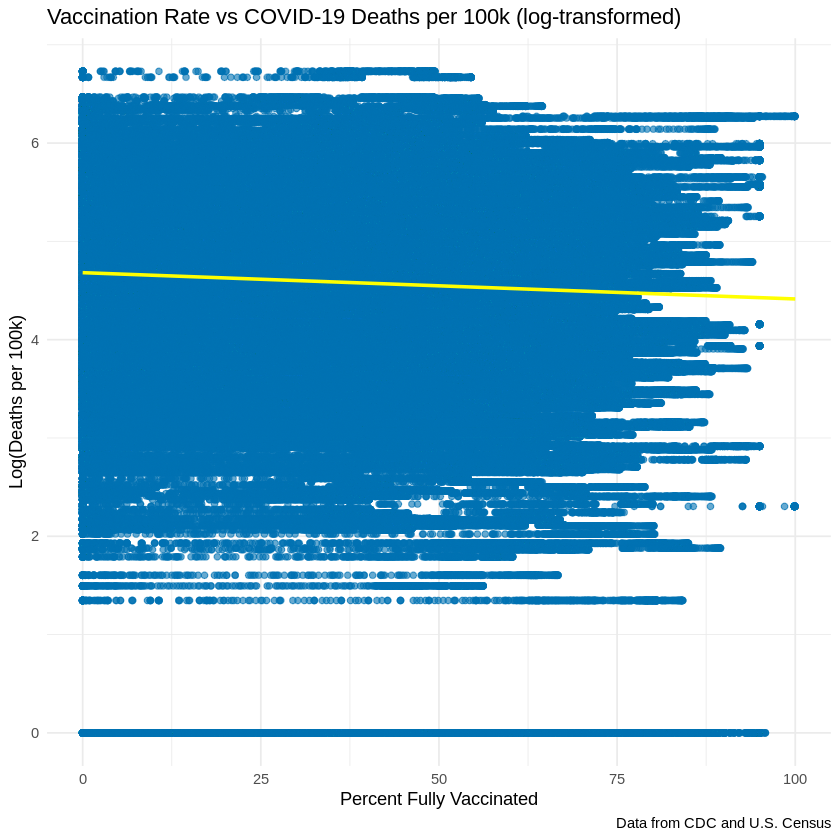

In [ ]:
# Scatter plot with semi-transparent blue points
ggplot(merged_data, aes(x = pct_fully_vaccinated, y = log_deaths_per_100k)) +
  # semi-transparent blue points
  geom_point(alpha = 0.6, color = "#0072B2") +

  # Add a linear regression line in yellow
  geom_smooth(method = "lm", color = "yellow") +

  labs(
    title = "Vaccination Rate vs COVID-19 Deaths per 100k (log-transformed)",
    x = "Percent Fully Vaccinated",
    y = "Log(Deaths per 100k)",
    caption = "Data from CDC and U.S. Census"
  ) +
  # minimal theme for better readability
  theme_minimal()



> **VISUALIZATION 2: Heatmap of Vaccination Rates by State**


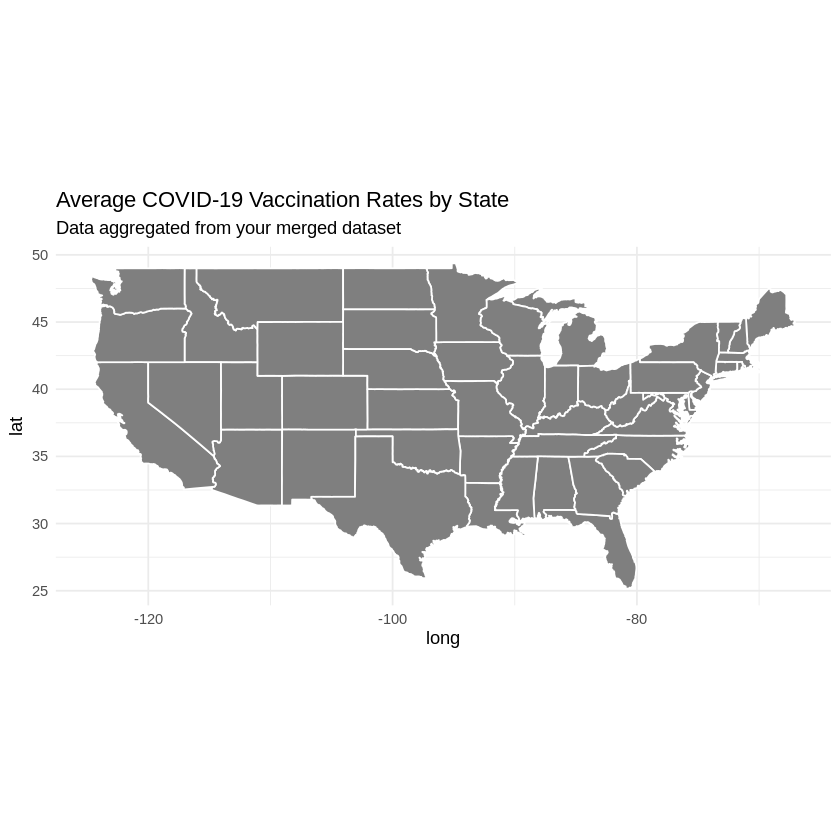

In [ ]:
# Calculate the average vaccination rate by state
state_vax <- merged_data %>%
  group_by(state) %>%
  summarise(avg_vax_rate = mean(pct_fully_vaccinated, na.rm = TRUE))

# Prepare the map data
states_map <- map_data("state")

# Ensure state names in 'state_vax' are lowercase to match the map data format
state_vax$region <- tolower(state_vax$state)

# Merge vaccination data with map data by state
map_df <- left_join(states_map, state_vax, by = "region")

# Create the heatmap of vaccination rates by state using ggplot2
ggplot(map_df, aes(x = long, y = lat, group = group, fill = avg_vax_rate)) +

  # Draw state boundaries
  geom_polygon(color = "white") +

  # Fix aspect ratio to avoid distortion
  coord_fixed(1.1) +
  scale_fill_viridis(name = "Avg Vax Rate", option = "plasma", direction = -1) + # Color scale

  # minimal theme for better readability
  theme_minimal() +

  labs(title = "Average COVID-19 Vaccination Rates by State",
       subtitle = "Data aggregated from your merged dataset") +
  theme(legend.position = "right")


> **VISUALIZATION 3:  Vaccination Uptake vs. Cases and Deaths (Snapshot Comparison)**

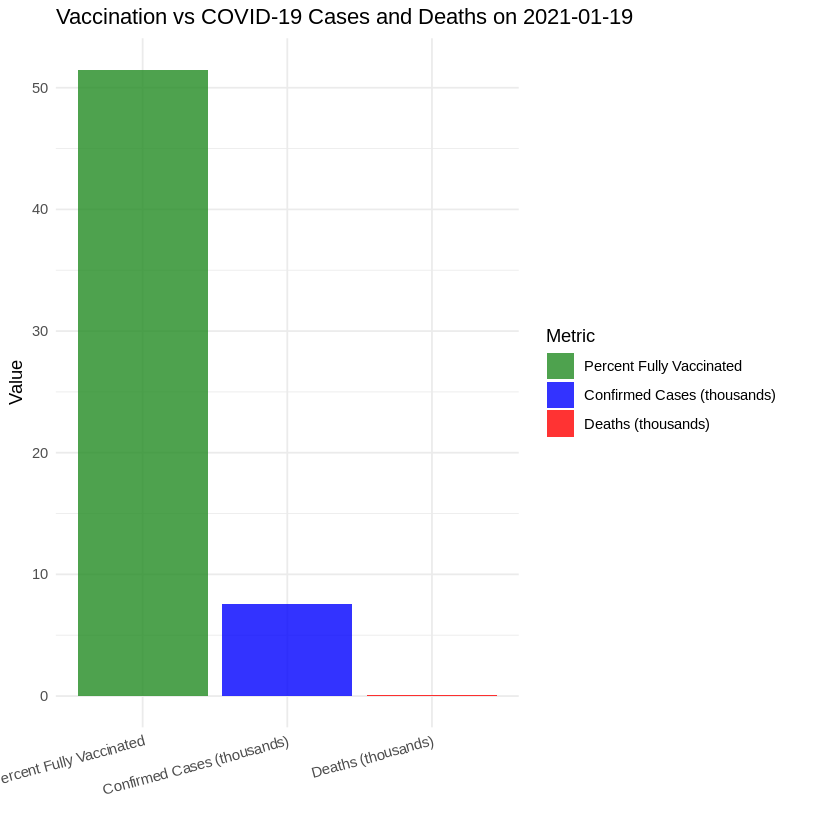

In [ ]:
# Prepare data in long format for grouped bar plot
plot_data <- merged_data %>%
  filter(date == as.Date("2021-01-19")) %>%
  # Summarize the average vaccination percentage, confirmed cases, and deaths
  summarise(
    # Average percent fully vaccinated
    pct_fully_vaccinated = mean(pct_fully_vaccinated, na.rm = TRUE),
    # Average confirmed cases (scaled to thousands)
    confirmed_cases_thousands = mean(confirmed_cases, na.rm = TRUE) / 1000,
    # Average deaths (scaled to thousands)
    deaths_thousands = mean(deaths, na.rm = TRUE) / 1000
  ) %>%
  # Convert data from wide to long format for easier plotting with ggplot2
  pivot_longer(
    cols = everything(),
    names_to = "metric",
    values_to = "value"
  ) %>%
  # Rename and order factor levels for better legend and x-axis labels
  mutate(
    metric = factor(metric, levels = c("pct_fully_vaccinated", "confirmed_cases_thousands", "deaths_thousands"),
                    labels = c("Percent Fully Vaccinated", "Confirmed Cases (thousands)", "Deaths (thousands)"))
  )

# Plot grouped bar chart using ggplot2
ggplot(plot_data, aes(x = metric, y = value, fill = metric)) +
  geom_col(alpha = 0.8) +
  scale_fill_manual(values = c("forestgreen", "blue", "red")) +
  labs(
    title = "Vaccination vs COVID-19 Cases and Deaths on 2021-01-19",
    x = "",
    y = "Value",
    fill = "Metric"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 15, hjust = 1))



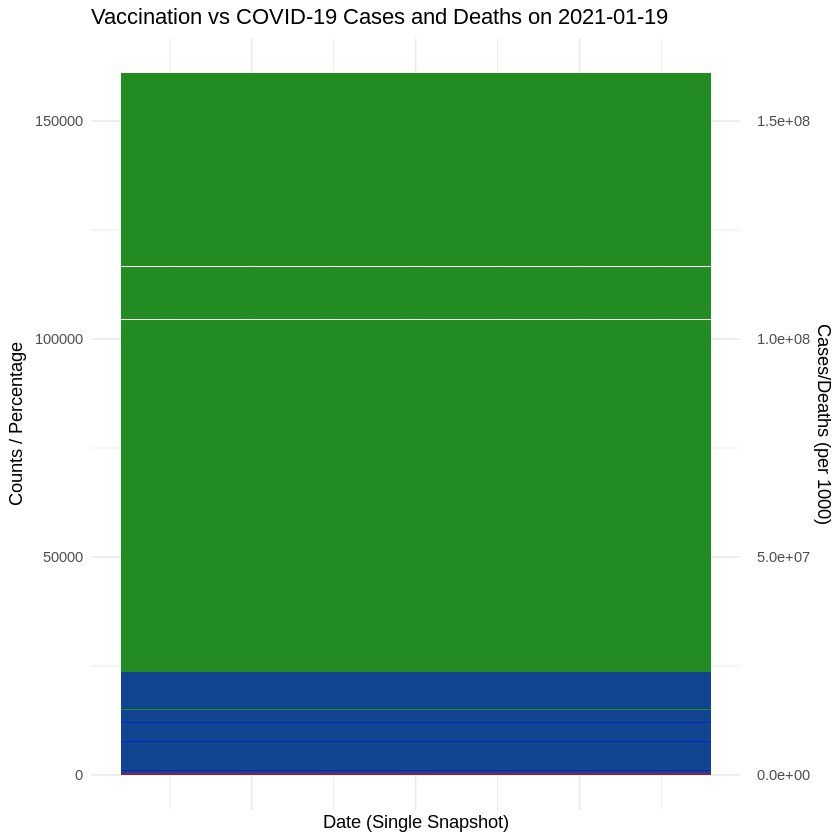

In [ ]:
# Plot the data for the single date
ggplot(merged_data, aes(x = 1)) +  # We use `x = 1` since it's a single point
  geom_bar(aes(y = pct_fully_vaccinated), stat = "identity", fill = "forestgreen") +
  geom_bar(aes(y = confirmed_cases / 1000), stat = "identity", fill = "blue", alpha = 0.5) +
  geom_bar(aes(y = deaths / 1000), stat = "identity", fill = "red", alpha = 0.5) +
  scale_y_continuous(
    name = "Counts / Percentage",
    sec.axis = sec_axis(~.*1000, name = "Cases/Deaths (per 1000)")
  ) +
  labs(
    title = "Vaccination vs COVID-19 Cases and Deaths on 2021-01-19",
    x = "Date (Single Snapshot)",
    y = "Percentage / Count"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_blank())  # Remove x-axis labels since it's just one date



> **Visualization 4: Plotting the Time Series**

In [ ]:
# Filter to county-level data only
mobility_counties <- us_mobility_imputed_complete %>%
  filter(!is.na(census_fips_code), !is.na(sub_region_2)) %>%
  rename(county_fips_code = census_fips_code) %>%
  # Select key features
  select(
    county_fips_code,
    state = sub_region_1,
    county_name = sub_region_2,
    date,
    retail_and_recreation_percent_change_from_baseline,
    grocery_and_pharmacy_percent_change_from_baseline,
    parks_percent_change_from_baseline,
    transit_stations_percent_change_from_baseline,
    workplaces_percent_change_from_baseline,
    residential_percent_change_from_baseline
  )

In [ ]:

time_series_summary <- merged_data %>%
  group_by(date) %>%
  summarise(
    total_cases = sum(confirmed_cases, na.rm = TRUE),
    total_deaths = sum(deaths, na.rm = TRUE),
    avg_vaccination = mean(pct_fully_vaccinated, na.rm = TRUE)
  )


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


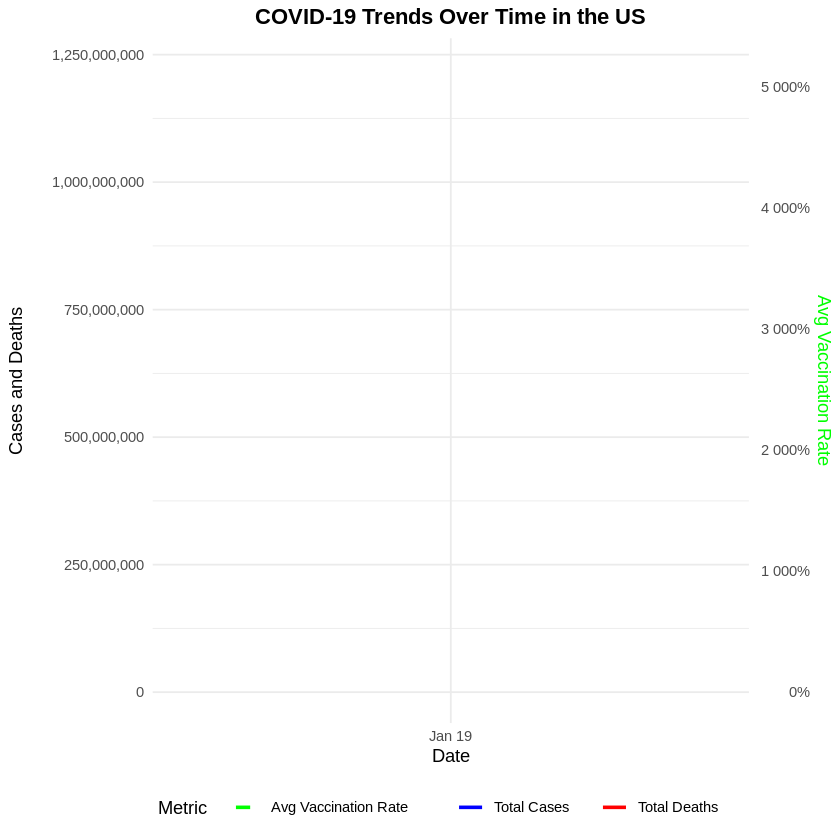

In [ ]:

ggplot(time_series_summary, aes(x = date)) +
  geom_line(aes(y = total_cases, color = "Total Cases", group = 1), linewidth = 1) +
  geom_line(aes(y = total_deaths, color = "Total Deaths", group = 1), linewidth = 1) +
  geom_line(
    aes(y = avg_vaccination * max(total_cases, na.rm = TRUE),
        color = "Avg Vaccination Rate", group = 1),
    linetype = "dashed", linewidth = 1
  ) +
  scale_y_continuous(
    name = "Cases and Deaths",
    labels = scales::comma,
    sec.axis = sec_axis(
      ~ . / max(time_series_summary$total_cases, na.rm = TRUE),
      name = "Avg Vaccination Rate",
      labels = scales::percent_format(accuracy = 1)
    )
  ) +
  scale_color_manual(
    name = "Metric",
    values = c("Total Cases" = "blue",
               "Total Deaths" = "red",
               "Avg Vaccination Rate" = "green")
  ) +
  labs(
    title = "COVID-19 Trends Over Time in the US",
    x = "Date"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    axis.title.y.right = element_text(color = "green"),
    axis.title.y.left = element_text(color = "black"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )



> **ANALYSIS: Linear Regression Model**

In [ ]:
# Create log-transformed population density to normalize its distribution
merged_data$log_pop_density <- log(merged_data$pop_density)

# Prepare data for linear regression: select relevant variables and remove rows with missing values
model_data <- merged_data %>%
  select(log_deaths_per_100k, pct_fully_vaccinated, log_pop_density, median_age, gini_index) %>%
  na.omit()

model <- lm(log_deaths_per_100k ~ pct_fully_vaccinated + log_pop_density + median_age + gini_index,
            data = model_data)

# summary(model)
model_data <- merged_data %>%
  select(log_deaths_per_100k, pct_fully_vaccinated, median_age, gini_index) %>%
  na.omit()

model <- lm(log_deaths_per_100k ~ pct_fully_vaccinated + median_age + gini_index,
            data = model_data)
summary(model)


#======
# Create log-transformed population density to normalize its distribution
merged_data$log_pop_density <- log(merged_data$pop_density)

# Prepare data for linear regression: select relevant variables and remove rows with missing values
model_data <- merged_data %>%
  select(log_deaths_per_100k, pct_fully_vaccinated, log_pop_density, median_age, gini_index) %>%
  na.omit()

# Fit linear regression model to predict log deaths per 100k using vaccination rate, population density, median age, and income inequality (Gini index)
model <- lm(log_deaths_per_100k ~ pct_fully_vaccinated + log_pop_density + median_age + gini_index,
            data = model_data)

# Alternatively, fit a simpler model excluding log_pop_density
model_data <- merged_data %>%
  select(log_deaths_per_100k, pct_fully_vaccinated, median_age, gini_index) %>%
  na.omit()

model <- lm(log_deaths_per_100k ~ pct_fully_vaccinated + median_age + gini_index,
            data = model_data)

# Display model summary to examine coefficients and significance
summary(model)



Call:
lm(formula = log_deaths_per_100k ~ pct_fully_vaccinated + median_age + 
    gini_index, data = model_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.1268 -0.3360  0.1868  0.5703  2.3383 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           3.170e+00  1.142e-02  277.51   <2e-16 ***
pct_fully_vaccinated -2.606e-03  3.427e-05  -76.05   <2e-16 ***
median_age           -1.539e-02  1.374e-04 -111.99   <2e-16 ***
gini_index            4.817e+00  2.073e-02  232.31   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.004 on 1872920 degrees of freedom
Multiple R-squared:  0.04057,	Adjusted R-squared:  0.04057 
F-statistic: 2.64e+04 on 3 and 1872920 DF,  p-value: < 2.2e-16


## 10. Save processed merged dataset

In [ ]:
# Save processed dataset for reproducibility
write_csv(merged_data, "merged_covid_vax_dataset.csv")

=============================
=============================

> #### **Setup: Install and Load Packages**

In [ ]:
# Install missing packages and load required libraries for time-series clustering

required_pkgs <- c("dtwclust", "tidyverse", "lubridate", "zoo", "pROC", "cluster", "proxy", "caret", "fpc", "future.apply")
installed <- rownames(installed.packages())
for(pk in required_pkgs) if(!pk %in% installed) install.packages(pk)

  > Tidyverse data manipulation, visualization

In [ ]:
# Check if 'tidyverse' is installed; if not, install it

if (!require("tidyverse", character.only = TRUE)) {
  install.packages("tidyverse", dependencies = TRUE)
  library(tidyverse)
} else {
  message("tidyverse is already installed.")
}


In [ ]:

# Check if installed; if not, install packages individually

if (!require(dtwclust)) {
  install.packages("dtwclust", dependencies = TRUE)
} else {
  message("dtwclust is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

dtwclust is already installed.



  > Lubridate: date handling

In [ ]:
# Check if installed; if not, install packages individually

if (!require(lubridate)) {
  install.packages("lubridate", dependencies = TRUE)
} else {
  message("lubridate is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

lubridate is already installed.



  > Zoo: rolling averages

In [ ]:
# Check if installed; if not, install packages individually

if (!require(zoo)) {
  install.packages("zoo", dependencies = TRUE)
} else {
  message("zoo is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

zoo is already installed.



  > RColorBrewer: color palettes

In [ ]:
# Check if installed; if not, install packages individually

if (!require(RColorBrewer)) {
  install.packages("RColorBrewer", dependencies = TRUE)
} else {
  message("RColorBrewer is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

RColorBrewer is already installed.



  > Proxy: distance calculations

In [ ]:
# Check if installed; if not, install packages individually

if (!require(proxy)) {
  install.packages("proxy", dependencies = TRUE)
} else {
  message("proxy is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

proxy is already installed.



  > Cluster: clustering metrics

In [ ]:
# Check if installed; if not, install packages individually

if (!require(cluster)) {
  install.packages("cluster", dependencies = TRUE)
} else {
  message("cluster is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

cluster is already installed.



  > Caret: Modeling Utitlities

In [ ]:
# Install via CDN
# install.packages("caret", repos = "http://cran.r-project.org", dependencies = TRUE)

# Install remotes and caret
# install.packages("remotes", dependencies = TRUE)
# library(remotes)
# remotes::install_cran("caret", dependencies = TRUE)

# Install via devtools::install_github
# install.packages("remotes", dependencies = TRUE)
# library(remotes)
# remotes::install_cran("caret", dependencies = TRUE)


  > pROC: AUC / ROC

In [ ]:
# Check if installed; if not, install packages individually

if (!require(pROC)) {
  install.packages("pROC", dependencies = TRUE)
} else {
  message("pROC is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

pROC is already installed.



  > mClust: ARI computation

In [ ]:
# Check if installed; if not, install packages individually

if (!require(mclust)) {
  install.packages("mclust", dependencies = TRUE)
} else {
  message("mclust is already installed.")
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

mclust is already installed.



  > fpc: cluster evaluation

In [ ]:

# Check if installed; if not, install packages individually

if (!require(fpc)) {
  install.packages("fpc", dependencies = TRUE)
} else {
  message("fpc is already installed.")
}



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

fpc is already installed.



In [ ]:
library(proxy)

In [ ]:
library(zoo)

In [ ]:
# Load libraries
library(dtwclust)
library(tidyverse)
library(lubridate)
library(zoo)
library(pROC)
library(cluster)
library(proxy)
library(caret)
library(fpc)

# Set reproducible seed
set.seed(42)

Loading required package: proxy


Attaching package: ‘proxy’


The following objects are masked from ‘package:stats’:

    as.dist, dist


The following object is masked from ‘package:base’:

    as.matrix


Loading required package: dtw

Loaded dtw v1.23-1. See ?dtw for help, citation("dtw") for use in publication.


dtwclust:
Setting random number generator to L'Ecuyer-CMRG (see RNGkind()).
To read the included vignettes type: browseVignettes("dtwclust").
See news(package = "dtwclust") after package updates.


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




> ### **Read and Prepare Data**

In [ ]:
# Read Data and Initial Processing - Read COVID-19 and mobility data
df <- read_csv("COVID19_TX_Merged.csv", col_types = cols(.default = "c"))

# Convert types for numeric columns and filter Texas counties
df <- df %>%
  mutate(date = as.Date(date)) %>%
  mutate_at(vars(confirmed_cases, new_cases, deaths, total_pop,
                 workplaces_percent_change_from_baseline,
                 retail_and_recreation_percent_change_from_baseline,
                 residential_percent_change_from_baseline), as.numeric) %>%
  filter(state == "TX")


> ### **Define Time Window Per County**

In [ ]:
# Align Time Series by First Case

window_length <- 42  # Number of days after first reported case

# Compute first case date per county
first_case <- df %>%
  group_by(county_fips_code, county_name) %>%
  arrange(date) %>%
  summarize(first_case_date = min(date[confirmed_cases > 0], na.rm = TRUE),
            total_pop = first(total_pop)) %>% ungroup()

# Merge first_case info back to main dataset
df2 <- df %>% left_join(first_case, by = c("county_fips_code", "county_name"))

# Filter counties with enough data and compute day index
df2 <- df2 %>%
  filter(!is.na(first_case_date)) %>%
  mutate(day_since_first = as.integer(date - first_case_date)) %>%
  filter(day_since_first >= 0 & day_since_first < window_length)

# Keep counties with ≥ 80% of observations
min_obs_required <- round(window_length * 0.8)
county_counts <- df2 %>% group_by(county_fips_code) %>% summarize(obs = n())
eligible_counties <- county_counts %>% filter(obs >= min_obs_required) %>% pull(county_fips_code)
df3 <- df2 %>% filter(county_fips_code %in% eligible_counties)

message("Eligible counties: ", length(unique(df3$county_fips_code)))


`summarise()` has grouped output by 'county_fips_code'. You can override using
the `.groups` argument.
Eligible counties: 254



> **Rename columns ending with .x**

In [ ]:
# Remove .x from df2 column/variables names
colnames(df2) <- gsub("\\.x$", "", colnames(df2))

# Remove .x from df3 column/variables names
colnames(df3) <- gsub("\\.x$", "", colnames(df3))

# data_merged <- data_merged %>%
#   rename(
#     county_name = county_name.x
#   )

> ### **Build Time Series Matrices**

In [ ]:
# Check for a single column
library(dplyr)
has_name(df3, "total_pop")

[1] TRUE

In [ ]:
paste(colnames(df2), collapse = ", ")

[1] "county_fips_code, county_name, state, date, confirmed_cases, deaths, new_cases, new_deaths, retail_and_recreation_percent_change_from_baseline, grocery_and_pharmacy_percent_change_from_baseline, parks_percent_change_from_baseline, transit_stations_percent_change_from_baseline, workplaces_percent_change_from_baseline, residential_percent_change_from_baseline, total_pop, cases_per_100k, deaths_per_100k, workplace_category, residential_category, pop_density, family_households, median_age, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop, two_or_more_races_pop, not_hispanic_pop, commuters_by_public_transportation, households, median_income, income_per_capita, housing_units, vacant_housing_units, median_rent, owner_occupied_housing_units, families_with_young_children, two_parent_families_with_young_children, one_parent_families_with_young_children, housing_units_renter_occupied, mobile_homes, civilian_labor_force, employed_pop, unemployed_pop, not_in_labor_force, pop_16_over, pop_in_labor_force, children, commuters_by_carpool, commuters_drove_alone, employed_agriculture_forestry_fishing_hunting_mining, employed_arts_entertainment_recreation_accommodation_food, employed_construction, employed_education_health_social, employed_finance_insurance_real_estate, employed_information, employed_manufacturing, employed_other_services_not_public_admin, employed_public_administration, employed_retail_trade, employed_science_management_admin_waste, employed_transportation_warehousing_utilities, employed_wholesale_trade, gini_index, graduate_professional_degree, group_quarters, high_school_including_ged, households_public_asst_or_food_stamps, in_undergrad_college, less_than_high_school_graduate, male_45_to_64, no_car, not_us_citizen_pop, poverty, walked_to_work, worked_at_home, workers_16_and_over, associates_degree, bachelors_degree, masters_degree, commuters_16_over, male_under_18, female_under_18, male_18_44, female_18_44, male_45_64, female_45_64, male_65_plus, female_65_plus, rent_cost_burdened, rent_severely_burdened, rent_not_burdened, commute_very_short, commute_short, commute_medium, commute_long, commute_very_long, dwellings_single_family, dwellings_small_multi, dwellings_large_multi, some_college, income_low, income_lower_middle, income_middle, income_upper_middle, income_high, first_case_date, total_pop.y, day_since_first"

In [ ]:
# Create Time-Series Matrices - Smooth cases per 10k population

df3 <- df3 %>%
  group_by(county_fips_code) %>%
  arrange(day_since_first) %>%
  mutate(new_cases = as.numeric(new_cases),
         cases_per10k = (new_cases / as.numeric(total_pop)) * 10000,
         cases_smooth = zoo::rollapply(cases_per10k, width = 7, FUN = mean, align = "right", fill = NA)) %>%
  ungroup()

# Smooth workplaces mobility
df3 <- df3 %>%
  group_by(county_fips_code) %>%
  arrange(day_since_first) %>%
  mutate(workplaces = workplaces_percent_change_from_baseline,
         workplaces_smooth = zoo::rollapply(workplaces, width = 7, FUN = mean, align = "right", fill = NA)) %>%
  ungroup()

# Pivot to wide matrices
cases_wide <- df3 %>%
  select(county_fips_code, day_since_first, cases_smooth) %>%
  pivot_wider(names_from = day_since_first, values_from = cases_smooth, names_prefix = "d") %>%
  arrange(county_fips_code)

mob_wide <- df3 %>%
  select(county_fips_code, day_since_first, workplaces_smooth) %>%
  pivot_wider(names_from = day_since_first, values_from = workplaces_smooth, names_prefix = "d") %>%
  arrange(county_fips_code)

# Merge and convert to matrices
ts_df <- cases_wide %>% left_join(mob_wide, by = "county_fips_code", suffix = c("_cases", "_mob"))
rownames(ts_df) <- ts_df$county_fips_code
cases_mat <- ts_df %>% select(starts_with("d")) %>% select(ends_with("_cases")) %>% as.matrix()
mob_mat   <- ts_df %>% select(starts_with("d")) %>% select(ends_with("_mob")) %>% as.matrix()

# Replace missing values with 0
cases_mat[is.na(cases_mat)] <- 0
mob_mat[is.na(mob_mat)] <- 0

# Optional z-normalization function
z_norm <- function(x) {
  m <- mean(x)
  s <- sd(x)
  if(is.na(s) || s == 0) return(rep(0, length(x)))
  (x - m) / s
}

# Convert matrices to list-of-series for dtwclust
cases_series <- lapply(seq_len(nrow(cases_mat)), function(i) cases_mat[i, ])
names(cases_series) <- rownames(ts_df)
mob_series <- lapply(seq_len(nrow(mob_mat)), function(i) mob_mat[i, ])
names(mob_series) <- rownames(ts_df)


Warning message:
“Setting row names on a tibble is deprecated.”


  > Instal future and future.apply

In [ ]:
# Check if installed else install packages individually
if (!require(future.apply)) {
  install.packages("future", dependencies = TRUE)
  install.packages("future.apply", dependencies = TRUE)
} else {
  message("future.apply is already installed.")
}
 # install.packages("future", repos = "https://cloud.r-project.org/", dependencies = TRUE)


In [ ]:
# Check if 'future' is installed
if (!require(future)) {
  message("Package 'future' is not installed.")
} else {
  message("Package 'future' is installed.")
}


Loading required package: future

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘future’”
Package 'future' is not installed.



> ### **Determine Optimal k and Fit Clustering**

In [ ]:
# OPTION-1 - More Efficient:

# Define the custom DTW distance function
dtw_distance <- function(a, b) {
  # Compute DTW distance between two time series using the dtw package
  dtw_result <- dtw::dtw(a, b, step.pattern = dtw::symmetric1)
  return(dtw_result$normalizedDistance)
}

# Precompute the DTW distance matrix using proxy::dist
dist_mat <- proxy::dist(cases_mat, method = dtw_distance)

# Plan for parallel execution using future.apply
library(future.apply)
plan(multisession, workers = 4)

k_range <- 2:6
# Silhouette and WSS calculation in parallel
sil_scores_cases <- future_sapply(k_range, function(k) {
  cl <- tsclust(cases_series, type = "partitional", k = k, distance = dist_mat, centroid = "dba", trace = FALSE, window.size = 10)
  avg_sil(dist_mat, cl@cluster)
})

wss_cases <- future_sapply(k_range, function(k) {
  cl <- tsclust(cases_series, type = "partitional", k = k, distance = dist_mat, centroid = "dba", trace = FALSE, window.size = 10)
  sum(cl@withinss)
})

# Find best k
best_k_cases <- k_range[which.max(sil_scores_cases)]
message("Best k (cases) by silhouette: ", best_k_cases)

# Final clustering using the best k
# Fit final clustering
k_final <- best_k_cases
cl_cases <- tsclust(cases_series, type = "partitional", k = best_k_cases, distance = dist_mat, centroid = "dba", trace = TRUE, window.size = 10, seed = 42)

# Extract cluster assignments
cluster_assign_cases <- data.frame(county_fips_code = names(cl_cases@cluster), cluster_cases = cl_cases@cluster, stringsAsFactors = FALSE)
write_csv(cluster_assign_cases, "indiv_ts_clusters_cases.csv")


ERROR: Error in library(future.apply): there is no package called ‘future.apply’


In [ ]:
# OPTION-2 - Less Efficient:


# Determine k via silhouette and fit clustering

avg_sil <- function(dist_mat, clustering) {
  sil <- silhouette(clustering, dist_mat)
  mean(sil[, 3])
}

k_range <- 2:6
sil_scores_cases <- numeric(length(k_range))
wss_cases <- numeric(length(k_range))

for(i in seq_along(k_range)) {
  k <- k_range[i]
  cl <- tsclust(cases_series, type = "partitional", k = k,
                distance = "dtw_basic", centroid = "dba", trace = FALSE, window.size = 10)
  dist_mat <- proxy::dist(cases_mat, method = function(a,b) dtw::dtw(a,b,step.pattern = dtw::symmetric1)$normalizedDistance)
  sil_scores_cases[i] <- avg_sil(dist_mat, cl@cluster)
  wss_cases[i] <- sum(cl@withinss)
  message("k=", k, " silhouette=", round(sil_scores_cases[i],3))
}

best_k_cases <- k_range[which.max(sil_scores_cases)]
message("Best k (cases) by silhouette: ", best_k_cases)

# Fit final clustering
k_final <- best_k_cases
cl_cases <- tsclust(cases_series, type = "partitional", k = k_final,
                    distance = "dtw_basic", centroid = "dba", trace = TRUE, window.size = 10, seed = 42)

# Extract cluster assignments
cluster_assign_cases <- data.frame(county_fips_code = names(cl_cases@cluster),
                                   cluster_cases = cl_cases@cluster, stringsAsFactors = FALSE)
write_csv(cluster_assign_cases, "indiv_ts_clusters_cases.csv")


> ### **Plot Cluster Medoids**

In [ ]:
# Visualize Cluster Medoids

png("fig_cluster_medoid_cases.png", width = 900, height = 600)
par(mfrow = c(1,1))
plot(NULL, xlim = c(0, window_length-1), ylim = range(cases_mat),
     xlab = "Days since 1st case", ylab = "Cases per 10k (smoothed)",
     main = paste0("Cluster medoids (cases), k=", k_final))
cols <- RColorBrewer::brewer.pal(max(3,k_final), "Set1")
for(ci in 1:k_final) {
  lines(0:(window_length-1), cl_cases@centroids[[ci]], col = cols[ci], lwd = 2)
}
legend("topright", legend = paste0("Cluster ", 1:k_final), col = cols[1:k_final], lwd = 2)
dev.off()


> ### **Supervised Evaluation**

In [ ]:
# Predict Later Outcomes Using Cluster Membership

deaths_by_county <- df %>%
  group_by(county_fips_code) %>%
  summarize(total_deaths = sum(as.numeric(new_deaths), na.rm = TRUE),
            deaths_per10k = (max(as.numeric(deaths), na.rm = TRUE) / max(as.numeric(total_pop), na.rm = TRUE)) * 10000) %>%
  ungroup()

eval_df <- cluster_assign_cases %>% left_join(deaths_by_county, by = "county_fips_code")
median_death <- median(eval_df$deaths_per10k, na.rm = TRUE)
eval_df <- eval_df %>% mutate(high_death = ifelse(deaths_per10k > median_death, 1, 0))

# Logistic regression with one-hot cluster predictors
eval_df$cluster_factor <- as.factor(eval_df$cluster_cases)
dummies <- model.matrix(~ cluster_factor - 1, data = eval_df)
model_df <- cbind(eval_df, dummies)

log_mod <- glm(high_death ~ ., data = model_df %>% select(high_death, starts_with("cluster_factor")), family = "binomial")
pred <- predict(log_mod, type = "response")
roc_obj <- pROC::roc(eval_df$high_death, pred)
auc_val <- pROC::auc(roc_obj)
message("AUC predicting high-death from early case-cluster membership: ", round(auc_val,3))

metrics <- tibble(k = k_final, silhouette = max(sil_scores_cases), AUC = as.numeric(auc_val))
write_csv(metrics, "indiv_ts_metrics.csv")


> ### **Cluster Stability**

In [ ]:
# Assess Cluster Stability via Bootstrapping

ari_vals <- numeric(10)
for(i in 1:10) {
  set.seed(100 + i)
  cl_i <- tsclust(cases_series, type = "partitional", k = k_final,
                  distance = "dtw_basic", centroid = "dba", seed = 100 + i, trace = FALSE, window.size = 10)
  ari_vals[i] <- mclust::adjustedRandIndex(cl_cases@cluster, cl_i@cluster)
}
stab_mean <- mean(ari_vals)
message("Cluster stability (mean ARI over 10 runs): ", round(stab_mean,3))

# Append stability to metrics
metrics$stability_ARI_mean <- stab_mean
write_csv(metrics, "indiv_ts_metrics.csv")


> ### **Save Final Cluster Assignments with Metadata**

In [ ]:
# === Cell 8: Save Cluster Assignments with County Metadata ===
meta <- first_case %>% filter(county_fips_code %in% cluster_assign_cases$county_fips_code)
final_out <- cluster_assign_cases %>% left_join(meta, by = "county_fips_code") %>%
  left_join(deaths_by_county %>% select(county_fips_code, deaths_per10k), by = "county_fips_code")
write_csv(final_out, "indiv_ts_cluster_assignments_full.csv")

message("Script complete. Outputs: indiv_ts_clusters_cases.csv, indiv_ts_metrics.csv, indiv_ts_cluster_assignments_full.csv, fig_cluster_medoid_cases.png")


In [ ]:
########################################################################
# indiv_tsclust.R
# Time-series clustering for graduate individual report (Option C)
# Purpose: Cluster Texas counties by early epidemic/mobility dynamics
# Input: COVID19_TX_Merged.csv (must contain county_fips_code, date,
#        new_cases or confirmed_cases, workplaces_percent_change..., etc.)
# Outputs:
# - indiv_ts_clusters.csv        (cluster assignment per county)
# - fig_cluster_medoid_cases.png (medoid plots for case trajectories)
# - fig_cluster_medoid_mob.png   (medoid plots for mobility trajectories)
# - indiv_ts_metrics.csv         (silhouette, AUC, stability)
# - indiv_ts_script_log.txt      (optional: a short run log)
#
# Required R packages: dtwclust, tidyverse, lubridate, zoo, pROC, cluster, proxy
########################################################################

# === 0. Setup: install/load packages ===
required_pkgs <- c("dtwclust", "tidyverse", "lubridate", "zoo", "pROC", "cluster", "proxy", "caret", "fpc")
installed <- rownames(installed.packages())
for(pk in required_pkgs) if(!pk %in% installed) install.packages(pk)
library(dtwclust); library(tidyverse); library(lubridate)
library(zoo); library(pROC); library(cluster); library(proxy); library(caret); library(fpc)

set.seed(42) # reproducibility

# === 1. Read data ===
df <- read_csv("COVID19_TX_Merged.csv", col_types = cols(.default = "c"))
# Convert types: adjust column names if needed
df <- df %>%
  mutate(date = as.Date(date)) %>%
  mutate_at(vars(confirmed_cases, new_cases, deaths, total_pop,
                 workplaces_percent_change_from_baseline,
                 retail_and_recreation_percent_change_from_baseline,
                 residential_percent_change_from_baseline), as.numeric) %>%
  filter(state == "TX")  # Texas only

# === 2. Define time window per county ===
# Option: Align each county series to the date of the first reported case in that county.
# Choose window_length = number of days to use after the county's first case (e.g., 42 days = 6 weeks).
window_length <- 42

# Create a helper table of first case date per county
first_case <- df %>%
  group_by(county_fips_code, county_name) %>%
  arrange(date) %>%
  summarize(first_case_date = min(date[confirmed_cases > 0], na.rm = TRUE),
            total_pop = first(total_pop)) %>% ungroup()

# Merge first_case back
df2 <- df %>% left_join(first_case, by = c("county_fips_code", "county_name"))

# Filter counties with a valid first_case_date and enough subsequent days
# Build aligned day index: day_since_first = 0,1,2,...,window_length-1
df2 <- df2 %>%
  filter(!is.na(first_case_date)) %>%
  mutate(day_since_first = as.integer(date - first_case_date)) %>%
  filter(day_since_first >= 0 & day_since_first < window_length)

# Only include counties with complete coverage (optional) or allow some missingness and impute
min_obs_required <- round(window_length * 0.8) # require 80% coverage
county_counts <- df2 %>% group_by(county_fips_code) %>% summarize(obs = n())

eligible_counties <- county_counts %>% filter(obs >= min_obs_required) %>% pull(county_fips_code)
df3 <- df2 %>% filter(county_fips_code %in% eligible_counties)

message("Eligible counties: ", length(unique(df3$county_fips_code)))

# === 3. Build time series matrices ===
# Series 1: new_cases per 10000 (or per-population scaled)
# Smooth with 7-day rolling mean to reduce noise
df3 <- df3 %>%
  group_by(county_fips_code) %>%
  arrange(day_since_first) %>%
  mutate(new_cases = as.numeric(new_cases),
         cases_per10k = (new_cases / as.numeric(total_pop)) * 10000,
         cases_smooth = zoo::rollapply(cases_per10k, width = 7, FUN = mean, align = "right", fill = NA)) %>%
  ungroup()

# Series 2: workplaces mobility percent change (smoothed)
df3 <- df3 %>%
  group_by(county_fips_code) %>%
  arrange(day_since_first) %>%
  mutate(workplaces = workplaces_percent_change_from_baseline,
         workplaces_smooth = zoo::rollapply(workplaces, width = 7, FUN = mean, align = "right", fill = NA)) %>%
  ungroup()

# Pivot to wide: rows = county, cols = day 0..window_length-1
cases_wide <- df3 %>%
  select(county_fips_code, day_since_first, cases_smooth) %>%
  pivot_wider(names_from = day_since_first, values_from = cases_smooth, names_prefix = "d") %>%
  arrange(county_fips_code)

mob_wide <- df3 %>%
  select(county_fips_code, day_since_first, workplaces_smooth) %>%
  pivot_wider(names_from = day_since_first, values_from = workplaces_smooth, names_prefix = "d") %>%
  arrange(county_fips_code)

# Ensure same county order and merge
ts_df <- cases_wide %>% left_join(mob_wide, by = "county_fips_code", suffix = c("_cases", "_mob"))
rownames(ts_df) <- ts_df$county_fips_code

# Remove county_fips_code column for time series matrices
cases_mat <- ts_df %>% select(starts_with("d")) %>% select(ends_with("_cases")) %>% as.matrix()
mob_mat   <- ts_df %>% select(starts_with("d")) %>% select(ends_with("_mob")) %>% as.matrix()

# Replace NA with small value 0 or impute by mean
cases_mat[is.na(cases_mat)] <- 0
mob_mat[is.na(mob_mat)] <- 0

# Optional: z-normalize each series (common practice for shape-based clustering)
z_norm <- function(x) {
  m <- mean(x)
  s <- sd(x)
  if(is.na(s) || s == 0) return(rep(0, length(x)))
  (x - m) / s
}
cases_ts_list <- apply(cases_mat, 1, z_norm)    # list-like (column per series)
mob_ts_list   <- apply(mob_mat, 1, z_norm)

# Convert to list-of-series required by dtwclust (each element is a numeric vector)
cases_series <- lapply(seq_len(nrow(cases_mat)), function(i) cases_mat[i, ])
names(cases_series) <- rownames(ts_df)
mob_series <- lapply(seq_len(nrow(mob_mat)), function(i) mob_mat[i, ])
names(mob_series) <- rownames(ts_df)

# === 4. Choose clustering approach ===
# Option 1: Cluster on case trajectories (shape-based) with DTW distance.
# Option 2: Cluster on mobility trajectories.
# Option 3: Multivariate time-series clustering (both cases + mobility) using tsclust with "sbd" or "dtw_basic".
#
# We'll run: 1) cases-only DTW clustering; 2) mobility-only DTW clustering; 3) combined multivariate DTW (if memory ok).

# Helper: function to compute average silhouette from pairwise distance
avg_sil <- function(dist_mat, clustering) {
  sil <- silhouette(clustering, dist_mat)
  mean(sil[, 3])
}

# === 4A. Determine k via silhouette/wss on a small range ===
k_range <- 2:6
sil_scores_cases <- numeric(length(k_range))
wss_cases <- numeric(length(k_range))
for(i in seq_along(k_range)) {
  k <- k_range[i]
  # Partitioning Around Medoids with DTW distance via tsclust (partitional) can be costly;
  # we use tsclust with type="partitional", distance="dtw_basic", centroid="dba"
  cl <- tsclust(cases_series, type = "partitional", k = k,
                distance = "dtw_basic", centroid = "dba", trace = FALSE, window.size = 10)
  # compute distance matrix with dtw (approx) using proxy's dtw if available
  dist_mat <- proxy::dist(cases_mat, method = function(a,b) dtw::dtw(a,b,step.pattern = dtw::symmetric1)$normalizedDistance)
  sil_scores_cases[i] <- avg_sil(dist_mat, cl@cluster)
  # WSS approx via sum of squared distances to medoid (fpc::cluster.stats could also be used)
  medoids <- cl@centroids
  # For simplicity approximate WSS using sum of intra-cluster distances:
  wss_cases[i] <- sum(cl@withinss)
  message("k=", k, " silhouette=", round(sil_scores_cases[i],3))
}

# Choose k with highest silhouette
best_k_cases <- k_range[which.max(sil_scores_cases)]
message("Best k (cases) by silhouette: ", best_k_cases)

# === 4B. Fit final clustering (cases-only) with chosen k ===
k_final <- best_k_cases
cl_cases <- tsclust(cases_series, type = "partitional", k = k_final,
                    distance = "dtw_basic", centroid = "dba", trace = TRUE, window.size = 10, seed = 42)

# Extract cluster assignments
cluster_assign_cases <- data.frame(county_fips_code = names(cl_cases@cluster),
                                   cluster_cases = cl_cases@cluster, stringsAsFactors = FALSE)

# Save cluster assignments
write_csv(cluster_assign_cases, "indiv_ts_clusters_cases.csv")

# === 5. Visualization: medoids / centroids ===
# Plot medoid series for each cluster (cases)
png("fig_cluster_medoid_cases.png", width = 900, height = 600)
par(mfrow = c(1,1))
plot(NULL, xlim = c(0, window_length-1), ylim = range(cases_mat), xlab = "Days since 1st case", ylab = "Cases per 10k (smoothed)",
     main = paste0("Cluster medoids (cases), k=", k_final))
cols <- RColorBrewer::brewer.pal(max(3,k_final), "Set1")
for(ci in 1:k_final) {
  medoid_idx <- cl_cases@centroid[[ci]]$index # centroid is a time series; dtwclust doc: centroids available
  lines(0:(window_length-1), cl_cases@centroids[[ci]], col = cols[ci], lwd = 2)
}
legend("topright", legend = paste0("Cluster ", 1:k_final), col = cols[1:k_final], lwd = 2)
dev.off()

# === 6. Supervised evaluation: Do early clusters predict later severe outcomes? ===
# Build a "later outcome" per county: cumulative deaths per 10k at a later date (e.g., 6 months after first_case_date)
# For simplicity, compute total deaths per10k across full dataset (or at a fixed later date if available)
deaths_by_county <- df %>%
  group_by(county_fips_code) %>%
  summarize(total_deaths = sum(as.numeric(new_deaths), na.rm = TRUE),
            deaths_per10k = (max(as.numeric(deaths), na.rm = TRUE) / max(as.numeric(total_pop), na.rm = TRUE)) * 10000) %>%
  ungroup()

# merge with cluster assignments (cases)
eval_df <- cluster_assign_cases %>% left_join(deaths_by_county, by = "county_fips_code")

# Define "high impact" as deaths_per10k > median (binary outcome)
median_death <- median(eval_df$deaths_per10k, na.rm = TRUE)
eval_df <- eval_df %>% mutate(high_death = ifelse(deaths_per10k > median_death, 1, 0))

# Simple model: cluster membership as predictor (one-hot) for high_death; compute AUC
eval_df$cluster_factor <- as.factor(eval_df$cluster_cases)
dummies <- model.matrix(~ cluster_factor - 1, data = eval_df)
model_df <- cbind(eval_df, dummies)
# logistic regression
log_mod <- glm(high_death ~ ., data = model_df %>% select(high_death, starts_with("cluster_factor")), family = "binomial")
pred <- predict(log_mod, type = "response")
roc_obj <- pROC::roc(eval_df$high_death, pred)
auc_val <- pROC::auc(roc_obj)
message("AUC predicting high-death from early case-cluster membership: ", round(auc_val,3))

# Save metrics
metrics <- tibble(k = k_final, silhouette = max(sil_scores_cases), AUC = as.numeric(auc_val))
write_csv(metrics, "indiv_ts_metrics.csv")

# === 7. Cluster stability (bootstrap) ===
# compute Adjusted Rand Index between multiple runs (quick stability check)
ari_vals <- numeric(10)
for(i in 1:10) {
  set.seed(100 + i)
  cl_i <- tsclust(cases_series, type = "partitional", k = k_final,
                  distance = "dtw_basic", centroid = "dba", seed = 100 + i, trace = FALSE, window.size = 10)
  ari_vals[i] <- mclust::adjustedRandIndex(cl_cases@cluster, cl_i@cluster)
}
stab_mean <- mean(ari_vals)
message("Cluster stability (mean ARI over 10 runs): ", round(stab_mean,3))

# Append stability to metrics
metrics$stability_ARI_mean <- stab_mean
write_csv(metrics, "indiv_ts_metrics.csv")

# === 8. Save final cluster assignment with county metadata ===
meta <- first_case %>% filter(county_fips_code %in% cluster_assign_cases$county_fips_code)
final_out <- cluster_assign_cases %>% left_join(meta, by = "county_fips_code") %>%
  left_join(deaths_by_county %>% select(county_fips_code, deaths_per10k), by = "county_fips_code")
write_csv(final_out, "indiv_ts_cluster_assignments_full.csv")

# === End ===
message("Script complete. Outputs: indiv_ts_clusters_cases.csv, indiv_ts_metrics.csv, indiv_ts_cluster_assignments_full.csv, fig_cluster_medoid_cases.png")
